# Diachronic Analysis of Classical Greek and Latin Corpora

This notebook analyzes texts from four open-source repositories of Greek and Latin literature:

**Greek:**
- **[PerseusDL/canonical-greekLit](https://github.com/PerseusDL/canonical-greekLit)** — canonical Greek literary tradition
- **[OpenGreekAndLatin/First1KGreek](https://github.com/OpenGreekAndLatin/First1KGreek)** — the first thousand years of Greek

**Latin:**
- **[PerseusDL/canonical-latinLit](https://github.com/PerseusDL/canonical-latinLit)** — canonical Latin literary tradition
- **[OpenGreekAndLatin/csel-dev](https://github.com/OpenGreekAndLatin/csel-dev)** — Corpus Scriptorum Ecclesiasticorum Latinorum (Latin Church Fathers)

All contain TEI XML files organized by CTS URNs. We extract original-language texts,
classify them by century, genre, and language, and visualize the distribution.
At the end we analyze which texts do and do not have English translations.

## 1. Setup and Dependencies

In [3]:
import os
import re
import glob
import subprocess
from collections import defaultdict
from pathlib import Path

from lxml import etree
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Clone the Repositories

Shallow clones to save time and disk space. Skip if directories already exist.
Covers both Greek and Latin corpora.

In [4]:
REPOS = {
    'perseus_greek': {
        'url': 'https://github.com/PerseusDL/canonical-greekLit.git',
        'dir': '/Users/gcrane/github/canonical-greekLit',
        'language': 'Greek',
    },
    'first1k': {
        'url': 'https://github.com/OpenGreekAndLatin/First1KGreek.git',
        'dir': '/Users/gcrane/github/First1KGreek',
        'language': 'Greek',
    },
    'perseus_latin': {
        'url': 'https://github.com/PerseusDL/canonical-latinLit.git',
        'dir': '/Users/gcrane/github/canonical-latinLit',
        'language': 'Latin',
    },
    'csel': {
        'url': 'https://github.com/OpenGreekAndLatin/csel-dev.git',
        'dir': '/Users/gcrane/github/csel-dev',
        'language': 'Latin',
    },
}

for name, info in REPOS.items():
    if not os.path.isdir(info['dir']):
        print(f"Cloning {name}...")
        subprocess.run(
            ['git', 'clone', '--depth', '1', info['url'], info['dir']],
            check=True,
        )
        print(f"  Done: {info['dir']}")
    else:
        print(f"Already present: {info['dir']}")

Already present: /Users/gcrane/github/canonical-greekLit
Already present: /Users/gcrane/github/First1KGreek
Already present: /Users/gcrane/github/canonical-latinLit
Already present: /Users/gcrane/github/csel-dev


## 3. Author-to-Century Mappings

### 3a. TLG-to-Century Mapping (Greek)

The Thesaurus Linguae Graecae (TLG) assigns each author a four-digit code.
Both Greek repos use these as directory names (e.g. `tlg0012` = Homer).

**Sources:** TLG Canon (Berkowitz & Squitier), Perseus Catalog, OCD entries.

In [5]:
# Mapping: TLG author number -> approximate floruit century
# Negative = BCE, Positive = CE
# This is a representative subset; extend as needed.

TLG_CENTURY = {
    # ---- Archaic period (8th–6th c. BCE) ----
    '0012': -8,   # Homer
    '0020': -7,   # Hesiod
    '0214': -7,   # Archilochus
    '0261': -7,   # Callinus
    '0260': -7,   # Tyrtaeus
    '0263': -7,   # Mimnermus
    '0262': -7,   # Semonides
    '0264': -6,   # Solon
    '0258': -6,   # Theognis
    '0009': -6,   # Sappho
    '0259': -6,   # Alcaeus
    '0265': -6,   # Stesichorus
    '0253': -6,   # Ibycus
    '0254': -6,   # Anacreon
    '0255': -5,   # Simonides
    '0033': -6,   # Pindar (early 5th but archaic tradition)
    '1220': -6,   # Aesop / Aesopic fables

    # ---- Classical period (5th–4th c. BCE) ----
    '0033': -5,   # Pindar (reassign to 5th)
    '0085': -5,   # Aeschylus
    '0011': -5,   # Sophocles
    '0006': -5,   # Euripides
    '0019': -5,   # Aristophanes
    '0013': -5,   # Bacchylides
    '0016': -5,   # Herodotus
    '0003': -5,   # Thucydides
    '0627': -5,   # Hippocrates / Hippocratic corpus
    '0081': -5,   # Antiphon (orator)
    '0026': -5,   # Andocides
    '0540': -5,   # Democritus
    '0527': -5,   # Empedocles
    '0086': -4,   # Lysias
    '0029': -4,   # Isocrates
    '0014': -4,   # Demosthenes
    '0028': -4,   # Aeschines (orator)
    '0030': -4,   # Hyperides
    '0032': -4,   # Lycurgus (orator)
    '0010': -4,   # Isaeus
    '0017': -4,   # Dinarchus
    '0059': -4,   # Plato
    '0086': -4,   # Lysias
    '0007': -4,   # Xenophon
    '0543': -4,   # Aristotle (some works span 4th c.)
    '0086': -4,   # Aristotle

    # ---- Hellenistic period (3rd–1st c. BCE) ----
    '0533': -3,   # Theophrastus
    '0541': -3,   # Epicurus
    '0553': -3,   # Menander
    '0533': -3,   # Theophrastus
    '0058': -3,   # Callimachus
    '0005': -3,   # Theocritus
    '0001': -3,   # Apollonius Rhodius
    '0004': -3,   # Aratus
    '0557': -2,   # Polybius
    '0613': -2,   # Diodorus Siculus (some put him in 1st BCE)
    '0613': -1,   # Diodorus Siculus
    '0008': -1,   # Athenaeus (sometimes 2nd/3rd CE, but TLG 0008 varies)
    '0099': -1,   # Dionysius of Halicarnassus
    '0057': -1,   # Posidonius
    '0093': -1,   # Philodemus

    # ---- Early Roman Imperial (1st–2nd c. CE) ----
    '0062': 1,    # Strabo
    '0527': 1,    # Philo of Alexandria (spans 1st BCE/CE)
    '0526': 1,    # Josephus
    '0007': -4,   # Xenophon (already set above)
    '0031': 1,    # Dio Chrysostom
    '0087': 1,    # Epictetus (via Arrian)
    '0046': 2,    # Plutarch
    '0018': 2,    # Appian
    '0363': 2,    # Ptolemy
    '0060': 2,    # Pausanias
    '0008': 2,    # Athenaeus (reassign to 2nd/3rd CE)
    '0034': 2,    # Lucian
    '0006': -5,   # Euripides (already set)
    '0527': 1,    # Philo (already set)
    '0556': 2,    # Artemidorus
    '0058': -3,   # Callimachus (already set)
    '0059': -4,   # Plato (already set)
    '0061': 2,    # Galen
    '0086': -4,   # Lysias (already set)
    '0090': 2,    # Arrian
    '0094': 2,    # Aelius Aristides
    '0007': -4,   # Xenophon (already set)
    '0535': 2,    # Marcus Aurelius
    '0525': 2,    # Aelian
    '0088': 2,    # Achilles Tatius
    '0032': -4,   # Lycurgus already set
    '0551': 2,    # Longus

    # ---- Later Imperial / Late Antique (3rd–5th c. CE) ----
    '0555': 3,    # Cassius Dio
    '0093': -1,   # Philodemus (already set)
    '2022': 3,    # Origen
    '2040': 3,    # Eusebius
    '2018': 3,    # Clement of Alexandria
    '2042': 4,    # John Chrysostom
    '2017': 4,    # Basil of Caesarea
    '2022': 3,    # Origen (already set)
    '2023': 3,    # Hippolytus
    '4089': 4,    # Gregory of Nazianzus
    '4090': 4,    # Gregory of Nyssa
    '2062': 4,    # Athanasius
    '5000': 5,    # Nonnus of Panopolis
    '2934': 5,    # Proclus
    '4015': 5,    # Stobaeus
    '0032': -4,   # already set
    '2959': 5,    # Simplicius
## more additions

    # ---- Hellenistic Period (3rd c. BCE) ----
    '0552': -3,    # Archimedes
    
    # ---- Roman Period (1st–3rd c. CE) ----
    '0559': 1,     # Hero of Alexandria
    '1271': 1,     # Clemens Romanus
    '0074': 2,     # Arrian
    '0563': 2,     # Maximus of Tyre
    '0592': 2,     # Hermogenes
    '0615': 2,     # Aspasius
    '0616': 2,     # Polyaenus
    '1764': 2,     # Vettius Valens
    '0638': 3,     # Philostratus the Athenian
    '0658': 3,     # Heliodorus of Emesa
    '2034': 3,     # Porphyry (Porphyrius)
    
    # ---- Late Antiquity (4th–7th c. CE) ----
    '2003': 4,     # Julian the Emperor
    '2035': 4,     # Athanasius
    '2045': 5,     # Nonnus of Panopolis
    '2048': 5,     # Sozomenus, Salaminius Hermias
    '2057': 5,     # Socrates Scholasticus
    '4017': 5,     # Syrianus
    '4020': 6,     # Elias Neoplatonicus
    '4021': 6,     # David the Invincible
    '4024': 6,     # Agathias Scholasticus
    '2371': 7,     # Chronicon Paschale
    
    # ---- Byzantine Period (11th–14th c. CE) ----
    '4034': 11,    # Michael of Ephesus
    '4030': 13,    # Sophonias
    
    # ---- Collective / Spurious / Unknown (NA) ----
    '0530': 'NA',  # Pseudo-Galen
    '4026': 'NA',  # Anonymi in Aristotelis Artem Rhetoricam
    '4033': 'NA',  # Anonymi In Aristotelis Ethica Nicomachea
    '5037': 'NA',  # Scholia in Sophoclem
    '7000': 'NA',  # Greek Anthology
}

# Deduplicated final mapping (last assignment wins above,
# so let's be explicit about the canonical values):
TLG_CENTURY_CLEAN = {
    '0012': -8, '0020': -7, '0214': -7, '0261': -7, '0260': -7,
    '0263': -7, '0262': -7, '0264': -6, '0258': -6, '0009': -6,
    '0259': -6, '0265': -6, '0253': -6, '0254': -6, '0255': -5,
    '1220': -6,
    '0033': -5, '0085': -5, '0011': -5, '0006': -5, '0019': -5,
    '0013': -5, '0016': -5, '0003': -5, '0627': -5, '0081': -5,
    '0026': -5, '0540': -5,
    '0086': -4, '0029': -4, '0014': -4, '0028': -4, '0030': -4,
    '0032': -4, '0010': -4, '0017': -4, '0059': -4, '0007': -4,
    '0543': -4,
    '0533': -3, '0541': -3, '0553': -3, '0058': -3, '0005': -3,
    '0001': -3, '0004': -3,
    '0557': -2, '0613': -1, '0099': -1, '0057': -1, '0093': -1,
    '0062':  1, '0527':  1, '0526':  1, '0031':  1, '0087':  1,
    '0046':  2, '0018':  2, '0363':  2, '0060':  2, '0008':  2,
    '0034':  2, '0556':  2, '0061':  2, '0090':  2, '0094':  2,
    '0535':  2, '0525':  2, '0088':  2, '0551':  2,
    '0555':  3, '2022':  3, '2040':  3, '2018':  3, '2023':  3,
    '2042':  4, '2017':  4, '4089':  4, '4090':  4, '2062':  4,
    '5000':  5, '2934':  5, '4015':  5, '2959':  5,
#}
# for simplicity just add this to the previous dictionary
#TLG_Century_est = {
    '0732': 3,    # Alexander of Aphrodisias (14 files, 1,249,457 words)
    '4013': 6,    # Simplicius (4 files, 1,140,771 words)
    '4102': 8,    # Catenae (Novum Testamentum) (32 files, 1,139,622 words) - compiled approx 6th-10th c.
    '5026': 10,   # Scholia in Homerum (2 files, 946,337 words) - Venetus A is 10th c.
    '2200': 4,    # Libanius (103 files, 715,749 words)
    '9010': 10,   # Suda (1 files, 583,818 words)
    '3135': 12,   # Joannes Zonaras (4 files, 467,911 words)
    '5023': 12,   # Scholia in Euripidem (8 files, 426,561 words) - mostly 11th-12th c.
    '0284': 2,    # Aelius Aristides (56 files, 321,227 words)
    '4016': 5,    # Ammonius (5 files, 289,666 words)
    '2021': 4,    # Epiphanius (3 files, 287,269 words)
    '2001': 4,    # Themistius (5 files, 285,061 words)
    '4031': 12,   # Eustratius (1 files, 264,213 words)
    '4029': 6,    # Procopius (2 files, 256,794 words)
    '1799': -3,   # Euclid (13 files, 244,566 words)
    '0544': 2,    # Sextus Empiricus (2 files, 221,578 words)
    '2000': 3,    # Plotinus (1 files, 214,015 words)
    '0082': 2,    # Apollonius Dyscolus (4 files, 202,634 words)
    '0385': 3,    # Cassius Dio Cocceianus (1 files, 191,358 words)
    '4018': 6,    # Asclepius (1 files, 190,402 words)
    '4019': 6,    # Olympiodorus (3 files, 184,977 words)
    '0612': 1,    # Dio Chrysostom (1 files, 178,358 words)
    '4036': 5,    # Proclus Diadochus (1 files, 175,197 words)
    '0656': 1,    # Dioscurides Pedianus (1 files, 170,756 words)
    '2703': 12,   # Anna Comnena (1 files, 162,386 words)
    '2115': 3,    # Hippolytus (2 files, 159,635 words)
    '0545': 3,    # Aelian (4 files, 157,254 words)
    '5034': 12,   # Scholia in Pindarum (3 files, 151,612 words) - often 12th c.
    '2703': 12,   # Annae Comnenae (1 files, 150,778 words)
    '1264': -3,   # Chrysippus (4 files, 148,150 words)

    ## more mappings

    # ---- Archaic/Classical (6th–4th c. BCE) ----
    '0096': -6,    # Aesop
    '1210': -4,    # Autolycus
    '0027': -4,    # Andocides

    # ---- Hellenistic Period (3rd–1st c. BCE) ----
    '0552': -3,    # Archimedes
    '0644': -3,    # Aristophanes of Byzantium
    '1431': -2,    # Hipparchus
    '1719': -2,    # Theodosius of Bithynia
    '0067': -2,    # Agatharchides
    '1595': -1,    # Philodemus
    '0529': -1,    # Arius Didymus
    '1383': -1,    # Geminus

    # ---- Roman Period (1st–3rd c. CE) ----
    '0559': 1,     # Hero of Alexandria
    '1271': 1,     # Clemens Romanus
    '0554': 1,     # Chariton
    '0628': 1,     # Musonius Rufus
    '0643': 1,     # Anonymus Londinensis
    '1194': 1,     # Aristonicus of Alexandria
    '0074': 2,     # Arrian
    '1764': 2,     # Vettius Valens
    '0592': 2,     # Hermogenes
    '0563': 2,     # Maximus of Tyre
    '0615': 2,     # Aspasius
    '0616': 2,     # Polyaenus
    '0645': 2,     # Justin Martyr
    '0565': 2,     # Soranus
    '0719': 2,     # Aretaeus of Cappadocia
    '0614': 2,     # Babrius
    '1724': 2,     # Theon Smyrnaeus
    '1725': 2,     # Theophilus
    '0358': 2,     # Nicomachus of Gerasa
    '0532': 2,     # Achilles Tatius
    '1205': 2,     # Athenagoras
    '1389': 2,     # Harpocration, Valerius
    '0548': 2,     # Apollodorus
    '0640': 2,     # Alciphron
    '0562': 2,     # Marcus Aurelius
    '1419': 2,     # Hermas
    '1443': 2,     # Ignatius of Antioch
    '1272': 2,     # Cleomedes
    '0023': 2,     # Oppian
    '1447': 2,     # Irenaeus
    '0317': 2,     # Acta Joannis
    '0098': 2,     # Zenobius Sophista
    '0561': 2,     # Longus
    '0053': 2,     # Phalaridis Epistulae (Pseudo-Phalaris)
    '0641': 2,     # Xenophon of Ephesus
    '0638': 3,     # Philostratus the Athenian
    '2034': 3,     # Porphyry
    '0015': 3,     # Herodian
    '2038': 3,     # Acta Thomae
    '2036': 3,     # Dexippus
    '2586': 3,     # Menander (Rhetor)
    '1600': 3,     # Philostratus Sophista
    '2027': 3,     # Valerius Apsines

    # ---- Late Antiquity (4th–7th c. CE) ----
    '2003': 4,     # Julian the Emperor
    '0658': 4,     # Heliodorus of Emesa
    '2035': 4,     # Athanasius of Alexandria
    '2032': 4,     # Pappus Alexandrinus
    '2046': 4,     # Quintus Smyrnaeus
    '2768': 4,     # Gelasius
    '2583': 4,     # Manetho Astrologus
    '0708': 4,     # Ammonius Grammaticus
    '2948': 4,     # Acta Philippi
    '2045': 5,     # Nonnus of Panopolis
    '2048': 5,     # Sozomenus, Salaminius Hermias
    '2057': 5,     # Socrates, Scholasticus
    '4017': 5,     # Syrianus
    '4084': 5,     # Zosimus
    '2058': 5,     # Philostorgius
    '2806': 5,     # Marcus Diaconus
    '4020': 6,     # Elias Neoplatonicus
    '4021': 6,     # David the Invincible
    '4024': 6,     # Agathias Scholasticus
    '2733': 6,     # Evagrius, Scholasticus
    '4072': 6,     # Eutocius
    '2371': 7,     # Chronicon Paschale
    '9019': 7,     # Stephanus of Alexandria

    # ---- Byzantine Period (11th–13th c. CE) ----
    '4034': 11,    # Michael of Ephesus
    '3118': 11,    # Syntipas
    '4030': 13,    # Sophonias
}

no_dates = {
    # ---- NA (Scholia, Collections, and Cumulative Texts) ----
    '7000': 'NA',  # Unknown
    '4033': 'NA',  # Anonymi In Aristotelis Ethica Nicomachea
    '4026': 'NA',  # Anonymi in Aristotelis Artem Rhetoricam
    '0530': 'NA',  # Pseudo-Galen
    '5037': 'NA',  # Scholia in Sophoclem
    '1551': 'NA',  # Oracula Sibyllina
    '5029': 'NA',  # Scholia in Lucianum
    '1286': 'NA',  # Anonymous
    '4027': 'NA',  # Anonymi in Aristotelis Categorias
    '5031': 'NA',  # Scholia in Nicandrum
    '5022': 'NA',  # Scholia in Euclidem
    '4193': 'NA',  # Anonymi in Aristotelis Sophisticos Elenchos
    '1482': 'NA',  # Cyranides
    '9004': 'NA',  # Anonymi In Aristotelis Librum Alterum Analyticorum Posteriorum
    '5019': 'NA',  # Anonymous
    '1765': 'NA',  # Vitae Aesopi
    '1463': 'NA',  # Liber Enoch
}
print(f"Mapped {len(TLG_CENTURY_CLEAN)} TLG author codes to centuries.")

Mapped 193 TLG author codes to centuries.


### 3b. PHI-to-Century Mapping (Latin — canonical-latinLit)

The Packard Humanities Institute (PHI) corpus assigns each Latin author a
four-digit code. The `canonical-latinLit` repo uses these as directory names
(e.g. `phi0690` = Virgil, `phi0474` = Cicero).

### 3c. STOA-to-Century Mapping (Latin — CSEL)

The CSEL repo uses STOA identifiers (e.g. `stoa0040` = Augustine).
Since these are Church Fathers, most fall in the 3rd–6th centuries CE.

**Sources:** PHI catalog, Oxford Classical Dictionary, CSEL volume metadata.

In [6]:
# ── PHI author code -> approximate floruit century ──
# Negative = BCE, Positive = CE

PHI_CENTURY = {
    # ---- Early Latin / Archaic (3rd–2nd c. BCE) ----
    '0057': -3,    # Naevius
    '0061': -3,    # Ennius
    '0119': -2,    # Plautus
    '0134': -2,    # Terence (Terentius)
    '0060': -2,    # Cato the Elder (Cato Maior)
    '0071': -2,    # Lucilius
    '0104': -2,    # Accius

    # ---- Late Republic (1st c. BCE) ----
    '0550': -1,    # Lucretius
    '0472': -1,    # Catullus
    '0474': -1,    # Cicero
    '0448': -1,    # Caesar
    '0588': -1,    # Sallust
    '0631': -1,    # Cornelius Nepos
    '0690': -1,    # Virgil (Vergilius)
    '0893': -1,    # Vitruvius
    '0660': -1,    # Tibullus
    '0707': -1,    # Propertius

    # ---- Augustan / Early Imperial (1st c. BCE – 1st c. CE) ----
    '0653': 1,     # Horace (Horatius) — straddles; floruit Augustan
    '0959': 1,     # Ovid (Ovidius)
    '0978': 1,     # Livy (Livius)
    '1056': 1,     # Hyginus
    '1221': 1,     # Manilius
    '0620': 1,     # Valerius Maximus
    '0845': 1,     # Columella
    '1254': 1,     # Pomponius Mela

    # ---- 1st century CE ----
    '0917': 1,     # Seneca the Elder
    '1017': 1,     # Seneca the Younger
    '0803': 1,     # Persius
    '0972': 1,     # Lucan
    '1011': 1,     # Petronius
    '0914': 1,     # Pliny the Elder
    '1010': 1,     # Valerius Flaccus
    '1241': 1,     # Curtius Rufus
    '0588': -1,    # Sallust (already set)
    '1351': 1,     # Silius Italicus
    '0895': 1,     # Statius
    '0660': -1,    # Tibullus (already set)
    '1318': 1,     # Calpurnius Siculus
    '1294': 1,     # Frontinus

    # ---- Late 1st – 2nd century CE ----
    '1315': 1,     # Martial
    '0395': 1,     # Quintilian
    '1348': 2,     # Suetonius
    '0683': 2,     # Pliny the Younger
    '1351': 1,     # Silius Italicus (already set)
    '0007': 2,     # Tacitus
    '1276': 2,     # Juvenal
    '0474': -1,    # Cicero (already set)
    '0020': 2,     # Fronto
    '0935': 2,     # Apuleius
    '0975': 2,     # Aulus Gellius
    '1002': 2,     # Florus
    '1212': 2,     # Gaius (jurist)

    # ---- 3rd century CE ----
    '2331': 3,     # Cyprian
    '2349': 3,     # Commodianus
    '2003': 3,     # Minucius Felix
    '0474': -1,    # Cicero (already set)

    # ---- 4th century CE ----
    '2806': 4,     # Lactantius
    '2349': 3,     # Commodianus (already set)
    '3131': 4,     # Ammianus Marcellinus
    '9500': 4,     # Claudian
    '1345': 4,     # Ausonius
    '2586': 4,     # Ambrose
    '0660': -1,    # Tibullus (already set)

    # ---- 5th–6th century CE ----
    '2349': 3,     # (already set)
}

# ── STOA author code -> approximate floruit century (CSEL / Church Fathers) ──

STOA_CENTURY = {
    '0040': 5,     # Augustine (354–430)
    '0238': 4,     # Rufinus of Aquileia
    '0076c': 5,    # John Cassian (c. 360–c. 435)
    '0058': 6,     # Boethius (d. 524)
    '0034': 4,     # Arnobius of Sicca (d. c. 330)
    '0054': 8,     # Bede the Venerable (673–735)
    '0223': 5,     # Paulinus of Nola (354–431)
    '0104d': 3,    # Tertullian (c. 155–c. 220)
    '0204a': 4,    # Orosius (c. 375–after 418)
    '0149a': 4,    # Jerome (Hieronymus) (c. 347–420)
    '0104e': 3,    # Novatian
    '0045a': 4,    # Papal epistles (various, ~4th c.)
    '0217': 5,     # Prosper of Aquitaine (c. 390–c. 455)
    '0255': 4,     # Sulpicius Severus (c. 363–c. 425)
    '0253': 6,     # Salvian (c. 400–c. 490)
    '0235': 5,     # Pope Leo I (c. 400–461)
    '0199': 5,     # Marius Mercator
    '0245': 4,     # Prudentius (348–after 405)
    '0111': 3,     # Cyprian (c. 210–258)
    '0088': 4,     # Commodianus
    '0105': 4,     # Optatus of Milevis
    '0202': 5,     # Orientius
    '0159': 4,     # Hilary of Poitiers
    '0219': 4,     # Priscillian
    '0165': 4,     # Itinerarium Egeriae
    '0078': 6,     # Cassiodorus (c. 485–c. 585)
    '0117': 5,     # Ennodius
    '0116': 5,     # Dracontius
    '0121': 4,     # Firmicus Maternus
    '0299': 5,     # Victor of Vita
    '0297': 5,     # Victor of Tunnuna
    '0215': 4,     # Philastrius
    '0163': 6,     # Iordanes (Jordanes)
    '0145': 5,     # Gennadius of Massilia
    '0002': 3,     # Arnobius iunior (scholia)
    '0283': 4,     # Vegetius (Publius Flavius Vegetius Renatus)
    '0267': 4,     # Symmachus
    '0276': 4,     # Tyconius
    '0250': 4,     # Sedulius
    '0239': 4,     # Ruricius of Limoges
    '0138': 5,     # Fulgentius
    '0210': 4,     # Pacianus of Barcelona
    '0195': 4,     # Lucifer of Cagliari
    '0184': 5,     # Julius Honorius (Cosmographia)
    '0269': 4,     # Theodorus Priscianus
    '0271': 4,     # Theodosius (diaconus)
    '0080': 4,     # Chromatius of Aquileia
    '0079': 4,     # Cento Probae (Proba)
    '0127': 5,     # Faustus of Riez
    '0060a': 5,    # Euippius (Eugippius)
    '0144': 5,     # Gerontius
    '0128': 5,     # Faustinus
    '0041': 5,     # Avitus of Vienne
    '0044': 4,     # Bachiarius
    '0178': 5,     # John of Biclar
    '0240': 4,     # Rutilius Namatianus
}

# Combine into a lookup that stores the 'no_dates' equivalent
STOA_NO_DATES = {
    # Anonymous or uncertain date
}

print(f"Mapped {len(PHI_CENTURY)} PHI author codes to centuries.")
print(f"Mapped {len(STOA_CENTURY)} STOA author codes to centuries.")

Mapped 56 PHI author codes to centuries.
Mapped 56 STOA author codes to centuries.


## 4. TEI XML Parsing Functions

Each XML file in these repos follows the CapiTainS/CTS convention:
- Greek repos: files named like `tlg0012.tlg001.perseus-grc2.xml`; `-grc` = Greek
- Latin repos: files named like `phi0474.phi014.perseus-lat2.xml`; `-lat` = Latin
- Translation files contain `-eng` (English) in their filename
- Poetry is marked with `<l>` (verse line) elements
- Prose is marked with `<p>` (paragraph) elements

In [7]:
# TEI and CTS namespaces used in these files
NS = {
    'tei': 'http://www.tei-c.org/ns/1.0',
    'ti': 'http://chs.harvard.edu/xmlns/cts',
}


def extract_author_code(filepath, code_prefix):
    """Extract the author code from a filepath given a prefix like 'tlg', 'phi', or 'stoa'.

    Paths look like: .../data/tlg0012/tlg001/tlg0012.tlg001.perseus-grc2.xml
                     .../data/phi0474/phi014/phi0474.phi014.perseus-lat2.xml
                     .../data/stoa0040/stoa003/stoa0040.stoa003.opp-lat1.xml
    We want the author part: '0012', '0474', '0040'.
    """
    parts = Path(filepath).parts
    for part in parts:
        m = re.match(rf'{code_prefix}(\d{{3,5}}[a-z]?)', part, re.IGNORECASE)
        if m:
            return m.group(1)
    return None


def is_original_edition(filepath: str, lang_code: str) -> bool:
    """Check if a file is an original-language edition (not a translation).

    lang_code: 'grc' for Greek, 'lat' for Latin
    """
    fname = os.path.basename(filepath).lower()
    return f'-{lang_code}' in fname and fname.endswith('.xml')


def classify_genre(tree: etree._ElementTree) -> str:
    """Classify a TEI XML document as 'poetry', 'prose', or 'mixed'.

    Strategy:
    1. Count <l> elements (verse lines) and <p> elements (paragraphs)
       inside the <body> or <text> of the document.
    2. Also check the refsDecl citation scheme — if the deepest
       cRefPattern references 'line' or 'l[@n', it's likely poetry.
    3. If verse lines dominate (>60% of structural elements), classify
       as poetry; if paragraphs dominate, classify as prose; otherwise mixed.
    """
    root = tree.getroot()

    # Try with TEI namespace first, then without (older files)
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        l_elements = root.findall(f'.//{ns_prefix}l')
        p_elements = root.findall(f'.//{ns_prefix}p')
        # Filter out <p> inside teiHeader (those are metadata, not text)
        header_tag = f'{ns_prefix}teiHeader'
        p_in_body = [
            p for p in p_elements
            if not any(anc.tag == header_tag for anc in p.iterancestors())
        ]

        n_lines = len(l_elements)
        n_paras = len(p_in_body)

        if n_lines + n_paras > 0:
            break

    # Also check citation scheme for 'line' patterns
    refs_text = ''
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        for refs in root.iter(f'{ns_prefix}refsDecl'):
            refs_text += etree.tostring(refs, encoding='unicode')

    has_line_citation = bool(re.search(r'line|/l\[|verse', refs_text, re.IGNORECASE))

    total = n_lines + n_paras
    if total == 0:
        # Fallback: check citation scheme
        return 'poetry' if has_line_citation else 'prose'

    line_ratio = n_lines / total

    if line_ratio > 0.6 or (line_ratio > 0.3 and has_line_citation):
        return 'poetry'
    elif line_ratio < 0.2:
        return 'prose'
    else:
        return 'mixed'


def count_words(tree: etree._ElementTree, language: str = 'Greek') -> int:
    """Count approximate words in the text body.

    For Greek: filters for lines containing Greek Unicode characters.
    For Latin: counts all whitespace-delimited tokens in the body
    (Latin uses standard ASCII/Latin-1 characters).
    """
    root = tree.getroot()

    # Find the body element
    body = None
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        body = root.find(f'.//{ns_prefix}body')
        if body is not None:
            break

    if body is None:
        for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
            body = root.find(f'.//{ns_prefix}text')
            if body is not None:
                break

    if body is None:
        return 0

    # Extract all text content
    all_text = ''.join(body.itertext())

    if language == 'Greek':
        greek_pattern = re.compile(r'[\u0370-\u03FF\u1F00-\u1FFF]')
        words = all_text.split()
        return len([w for w in words if greek_pattern.search(w)])
    else:
        # Latin: count tokens that contain at least one letter
        words = all_text.split()
        return len([w for w in words if re.search(r'[a-zA-ZÀ-ÿ]', w)])


def extract_author_name(tree: etree._ElementTree) -> str:
    """Try to extract author name from the TEI header."""
    root = tree.getroot()
    for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
        author = root.find(f'.//{ns_prefix}author')
        if author is not None and author.text:
            return author.text.strip()
    return 'Unknown'

## 5. Scan All Repositories

Walk through all XML files in each repo.
- For Greek repos: keep only files with `-grc` (Greek-language editions)
- For Latin repos: keep only files with `-lat` (Latin-language editions)
- CSEL has two layouts: CTS-structured `data/` directory and bulk `Volumes/` directory

For each file, record: author code, century, genre, word count, source repo, language.

In [8]:
def scan_repo(repo_dir, repo_label, lang_code, code_prefix, century_lookup,
              sub_dirs=None):
    """Scan a repository and extract metadata for each text.

    Parameters
    ----------
    repo_dir : str        – root of the cloned repository
    repo_label : str      – human-readable label (e.g. 'Perseus-Greek')
    lang_code : str       – 'grc' or 'lat'
    code_prefix : str     – 'tlg', 'phi', or 'stoa'
    century_lookup : dict – mapping author code -> century
    sub_dirs : list       – subdirectories to scan (default: ['data'])
    """
    language = 'Greek' if lang_code == 'grc' else 'Latin'
    if sub_dirs is None:
        sub_dirs = ['data']

    xml_files = []
    for sd in sub_dirs:
        search_dir = os.path.join(repo_dir, sd)
        if os.path.isdir(search_dir):
            xml_files.extend(
                glob.glob(os.path.join(search_dir, '**', '*.xml'), recursive=True)
            )
    print(f"  Found {len(xml_files)} total XML files in {repo_label}")

    # Filter to original-language editions only
    orig_files = [f for f in xml_files if is_original_edition(f, lang_code)]
    print(f"  Of which {len(orig_files)} are {language}-language editions")

    records = []
    errors = 0

    for i, filepath in enumerate(orig_files):
        if (i + 1) % 100 == 0:
            print(f"    Processing {i+1}/{len(orig_files)}...")

        try:
            tree = etree.parse(filepath)
        except etree.XMLSyntaxError:
            errors += 1
            continue

        author_code = extract_author_code(filepath, code_prefix)
        if author_code is None:
            # For CSEL Volumes files, try to extract from the XML content
            root = tree.getroot()
            for ns_prefix in ['{http://www.tei-c.org/ns/1.0}', '']:
                author_el = root.find(f'.//{ns_prefix}author')
                if author_el is not None:
                    ref = author_el.get('ref', '')
                    m = re.search(rf'{code_prefix}(\d{{3,5}}[a-z]?)', ref)
                    if m:
                        author_code = m.group(1)
                        break
        if author_code is None:
            author_code = 'unknown'

        century = century_lookup.get(author_code)
        genre = classify_genre(tree)
        word_count = count_words(tree, language)
        author = extract_author_name(tree)

        records.append({
            'file': os.path.basename(filepath),
            'filepath': filepath,
            'repo': repo_label,
            'author_code': author_code,
            'author': author,
            'century': century,
            'genre': genre,
            'word_count': word_count,
            'language': language,
        })

    if errors:
        print(f"  Skipped {errors} files with XML parse errors")

    return records


# ── Scan Greek repos ──
print("Scanning Perseus canonical-greekLit...")
greek_perseus = scan_repo(
    REPOS['perseus_greek']['dir'], 'Perseus-Greek', 'grc', 'tlg', TLG_CENTURY_CLEAN)

print("\nScanning First1KGreek...")
first1k = scan_repo(
    REPOS['first1k']['dir'], 'First1KGreek', 'grc', 'tlg', TLG_CENTURY_CLEAN)

# ── Scan Latin repos ──
print("\nScanning Perseus canonical-latinLit...")
latin_perseus = scan_repo(
    REPOS['perseus_latin']['dir'], 'Perseus-Latin', 'lat', 'phi', PHI_CENTURY)

print("\nScanning CSEL...")
csel = scan_repo(
    REPOS['csel']['dir'], 'CSEL', 'lat', 'stoa', STOA_CENTURY,
    sub_dirs=['data', 'Volumes', 'UniKonstanz'])

# ── Combine ──
all_records = greek_perseus + first1k + latin_perseus + csel
df = pd.DataFrame(all_records)

print(f"\n{'='*50}")
print(f"Total records: {len(df)}")
for lang in ['Greek', 'Latin']:
    sub = df[df['language'] == lang]
    print(f"\n  {lang}:")
    print(f"    Total files:          {len(sub)}")
    print(f"    With known century:   {sub['century'].notna().sum()}")
    print(f"    With unknown century: {sub['century'].isna().sum()}")
    print(f"    Genre distribution:")
    print(sub['genre'].value_counts().to_string(header=False))

Scanning Perseus canonical-greekLit...
  Found 2539 total XML files in Perseus-Greek
  Of which 814 are Greek-language editions
    Processing 100/814...
    Processing 200/814...
    Processing 300/814...
    Processing 400/814...
    Processing 500/814...
    Processing 600/814...
    Processing 700/814...
    Processing 800/814...

Scanning First1KGreek...
  Found 2613 total XML files in First1KGreek
  Of which 1124 are Greek-language editions
    Processing 100/1124...
    Processing 200/1124...
    Processing 300/1124...
    Processing 400/1124...
    Processing 500/1124...
    Processing 600/1124...
    Processing 700/1124...
    Processing 800/1124...
    Processing 900/1124...
    Processing 1000/1124...
    Processing 1100/1124...

Scanning Perseus canonical-latinLit...
  Found 1086 total XML files in Perseus-Latin
  Of which 428 are Latin-language editions
    Processing 100/428...
    Processing 200/428...
    Processing 300/428...
    Processing 400/428...
  Skipped 19 file

## 6. Data Cleaning

Filter to texts with known century assignments and nonzero word counts.
Create human-readable century labels.

In [9]:
# Filter to dated texts with actual content
df_dated = df.dropna(subset=['century']).copy()
df_dated = df_dated[df_dated['word_count'] > 0].copy()
df_dated['century'] = df_dated['century'].astype(int)

# Nicer labels
ordinal_suffixes = {1: 'st', 2: 'nd', 3: 'rd'}

def century_label(c: int) -> str:
    ac = abs(c)
    suffix = ordinal_suffixes.get(ac, 'th')
    era = 'BCE' if c < 0 else 'CE'
    return f"{ac}{suffix} c. {era}"

df_dated['century_label'] = df_dated['century'].apply(century_label)

# Sort order for centuries (chronological: -8, -7, ... -1, 1, 2, ...)
century_order = sorted(df_dated['century'].unique())
century_labels_ordered = [century_label(c) for c in century_order]

for lang in ['Greek', 'Latin']:
    sub = df_dated[df_dated['language'] == lang]
    print(f"\n{lang}:")
    print(f"  Dated texts with content: {len(sub)}")
    print(f"  Total words:              {sub['word_count'].sum():,}")
    crange = sorted(sub['century'].unique())
    if crange:
        print(f"  Century range:            {century_label(crange[0])} to {century_label(crange[-1])}")


Greek:
  Dated texts with content: 1646
  Total words:              34,690,370
  Century range:            8th c. BCE to 13th c. CE

Latin:
  Dated texts with content: 371
  Total words:              10,001,387
  Century range:            2nd c. BCE to 8th c. CE


## 7. Visualization 1: Textual Data by Century (Greek vs. Latin)

A stacked bar chart showing the total word count per century,
split by language and source repo.

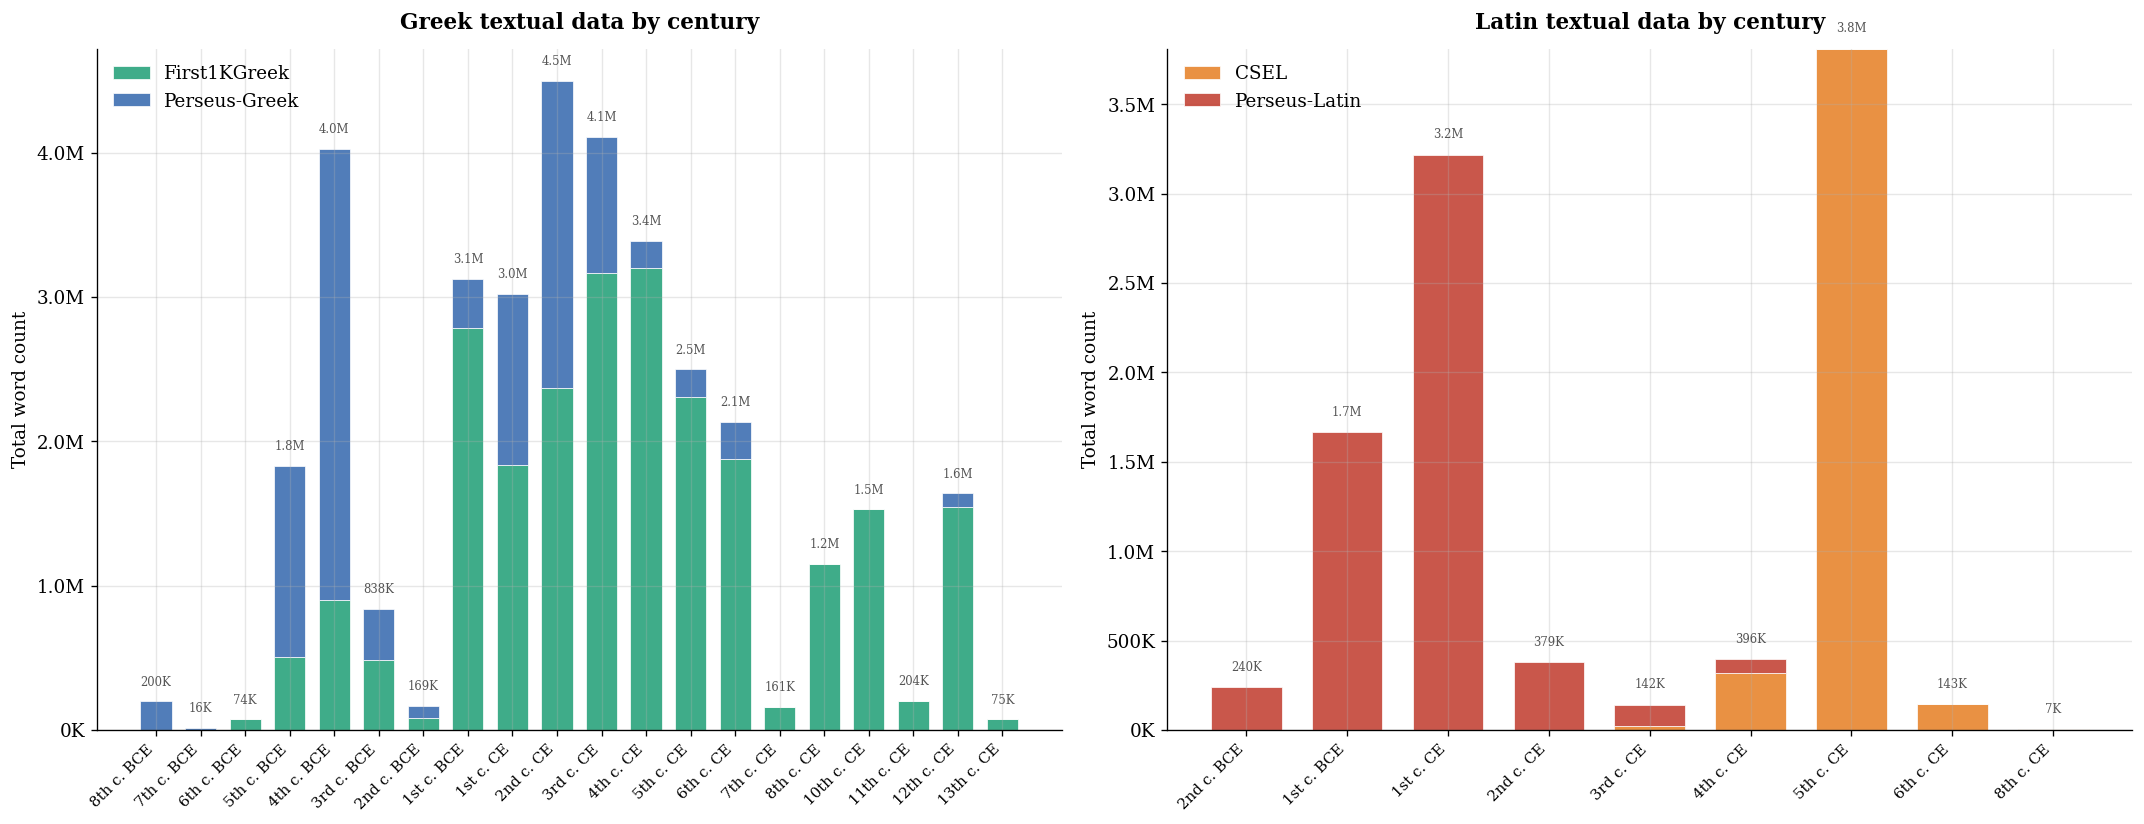

Saved: 01_greek_latin_by_century.png


In [10]:
# ---- Plot: Word count by century, Greek vs Latin side by side ----

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, lang in zip(axes, ['Greek', 'Latin']):
    sub = df_dated[df_dated['language'] == lang]
    if len(sub) == 0:
        ax.set_title(f'{lang}: no data')
        continue

    lang_centuries = sorted(sub['century'].unique())
    lang_labels = [century_label(c) for c in lang_centuries]

    pivot = sub.pivot_table(
        index='century', columns='repo', values='word_count',
        aggfunc='sum', fill_value=0
    ).reindex(lang_centuries, fill_value=0)

    x = np.arange(len(lang_centuries))
    width = 0.7

    # Color palette per repo
    repo_colors = {
        'Perseus-Greek': '#3266ad',
        'First1KGreek': '#1D9E75',
        'Perseus-Latin': '#C0392B',
        'CSEL': '#E67E22',
    }

    bottom = np.zeros(len(lang_centuries))
    for repo in pivot.columns:
        vals = pivot[repo].values
        ax.bar(x, vals, width, bottom=bottom, label=repo,
               color=repo_colors.get(repo, '#888'), alpha=0.85,
               edgecolor='white', linewidth=0.5)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(lang_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Total word count')
    ax.set_title(f'{lang} textual data by century', fontsize=13, fontweight='bold', pad=12)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
    ax.legend(frameon=False, loc='upper left')

    # Annotate totals
    totals = pivot.sum(axis=1).reindex(lang_centuries, fill_value=0)
    for i, total in enumerate(totals):
        if total > 0:
            label = f'{total/1e6:.1f}M' if total >= 1e6 else f'{total/1e3:.0f}K'
            ax.text(i, total + totals.max() * 0.02, label,
                    ha='center', va='bottom', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('01_greek_latin_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_greek_latin_by_century.png")

## 8. Visualization 2: Prose vs. Poetry by Century

Stacked percentage bar charts showing the proportion of prose, poetry, and
mixed texts for each language.

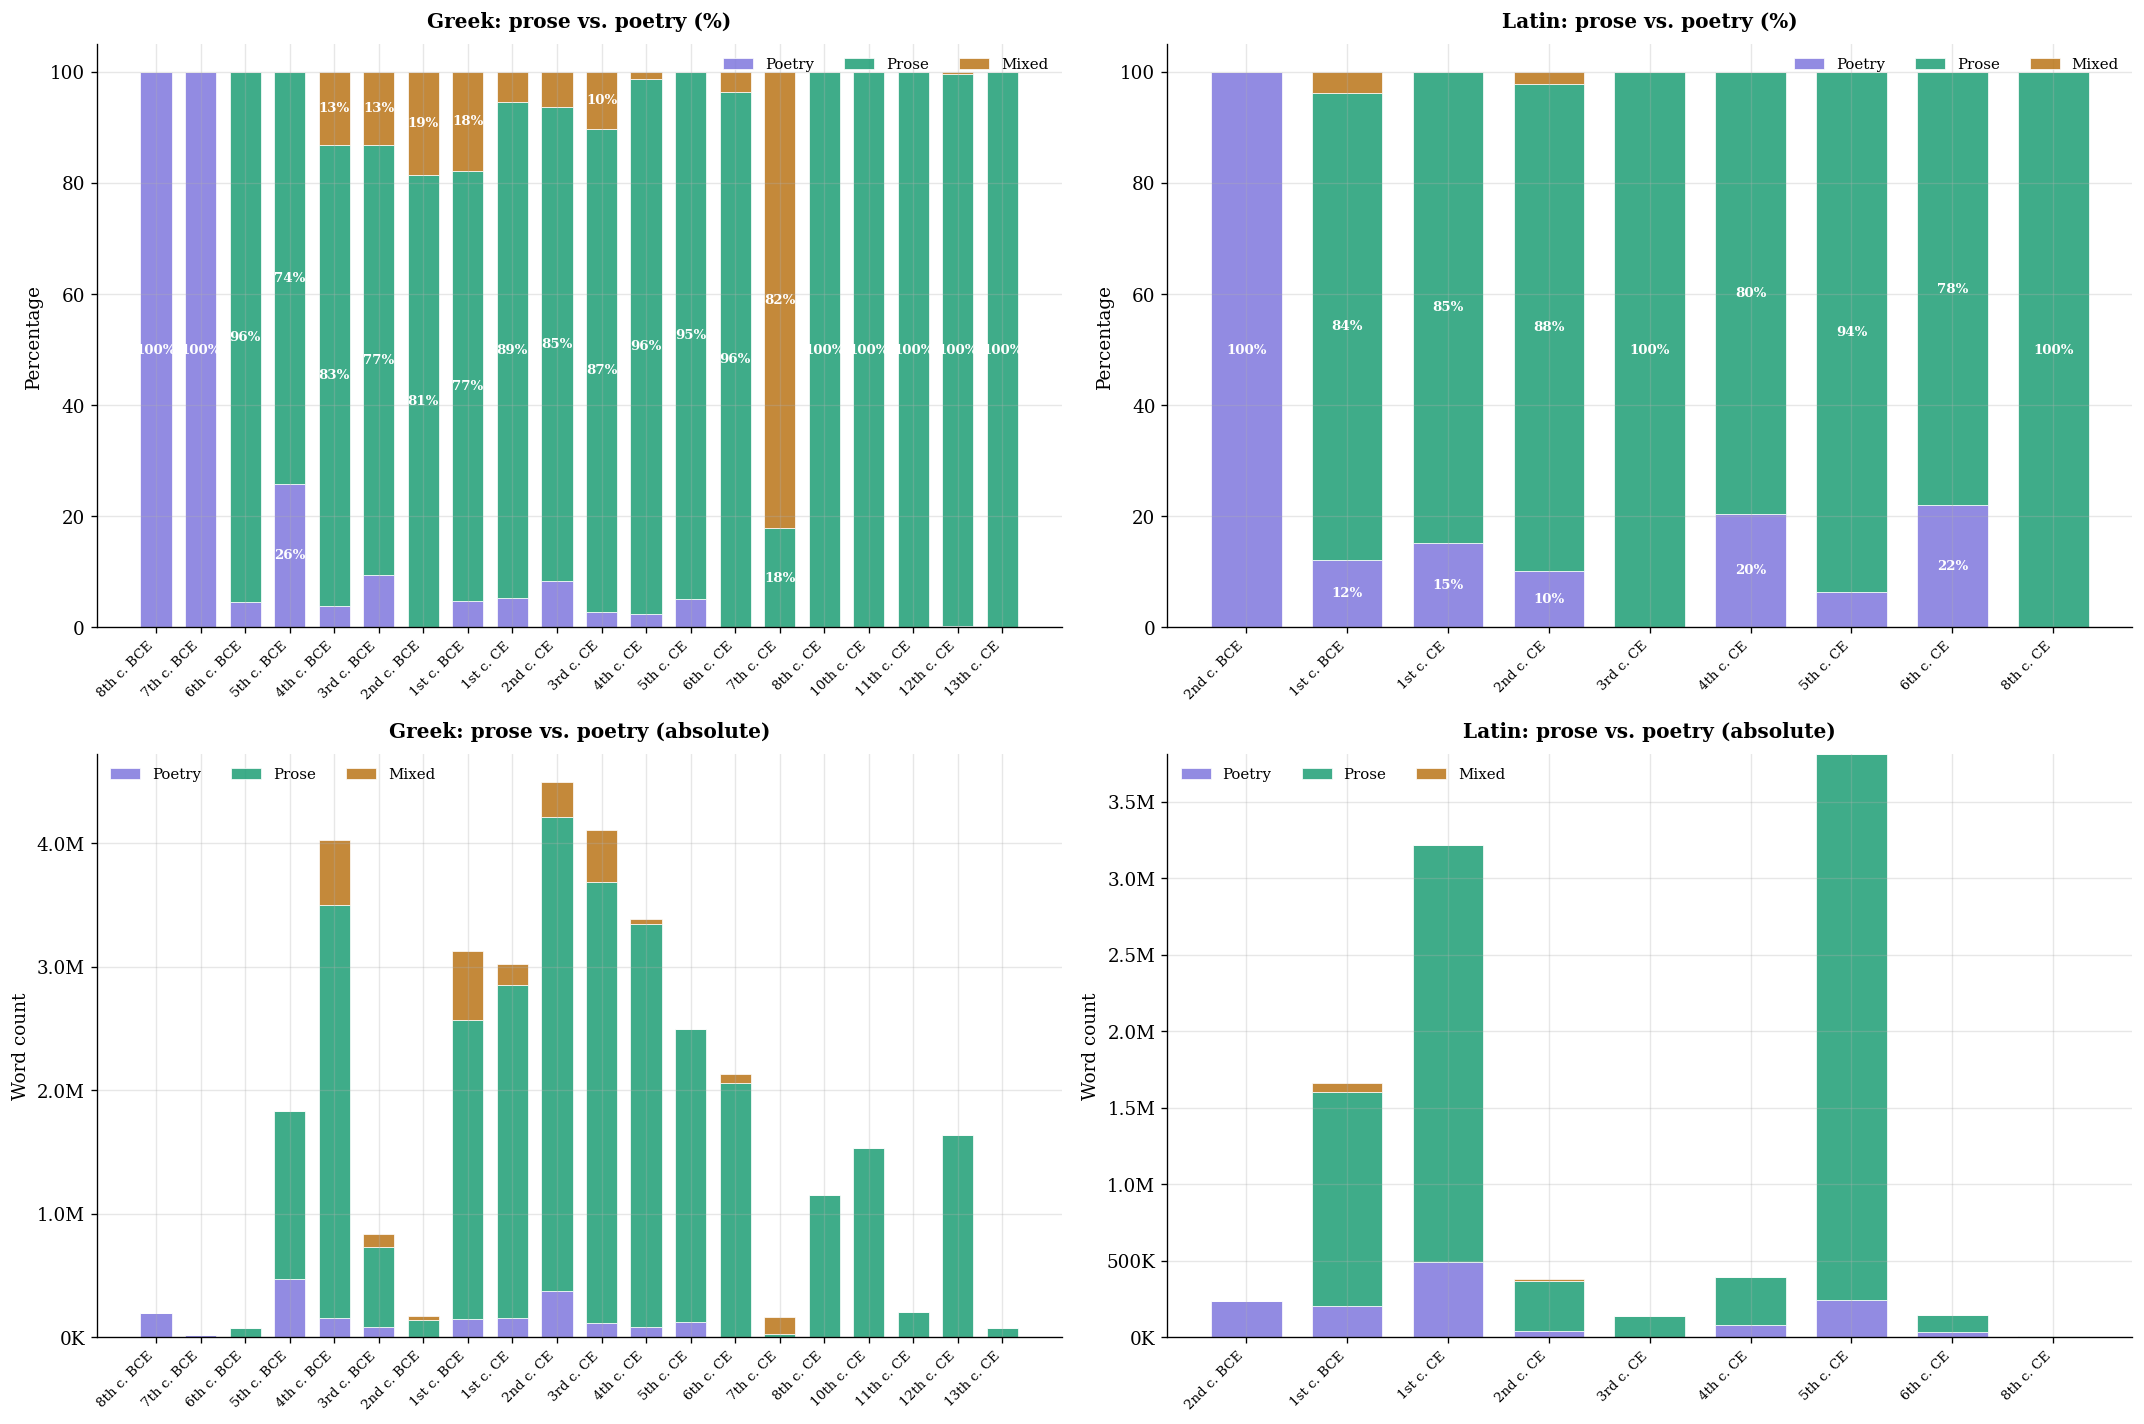

Saved: 02_prose_vs_poetry_by_century.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12),
                        gridspec_kw={'height_ratios': [1, 1]})

genre_colors = {'poetry': '#7F77DD', 'prose': '#1D9E75', 'mixed': '#BA7517'}

for col, lang in enumerate(['Greek', 'Latin']):
    sub = df_dated[df_dated['language'] == lang]
    if len(sub) == 0:
        continue

    lang_centuries = sorted(sub['century'].unique())
    lang_labels = [century_label(c) for c in lang_centuries]

    genre_pivot = sub.pivot_table(
        index='century', columns='genre', values='word_count',
        aggfunc='sum', fill_value=0
    ).reindex(lang_centuries, fill_value=0)

    for g in ['prose', 'poetry', 'mixed']:
        if g not in genre_pivot.columns:
            genre_pivot[g] = 0

    genre_totals = genre_pivot.sum(axis=1)
    genre_pct = genre_pivot.div(genre_totals, axis=0) * 100
    genre_pct = genre_pct.fillna(0)

    x = np.arange(len(lang_centuries))
    width = 0.7

    # Top: percentage
    ax_top = axes[0, col]
    bottom = np.zeros(len(lang_centuries))
    for genre in ['poetry', 'prose', 'mixed']:
        vals = genre_pct[genre].values
        ax_top.bar(x, vals, width, bottom=bottom, label=genre.capitalize(),
                   color=genre_colors[genre], alpha=0.85, edgecolor='white', linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v >= 10:
                ax_top.text(i, b + v/2, f'{v:.0f}%',
                           ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ax_top.set_xticks(x)
    ax_top.set_xticklabels(lang_labels, rotation=45, ha='right', fontsize=8)
    ax_top.set_ylabel('Percentage')
    ax_top.set_title(f'{lang}: prose vs. poetry (%)', fontsize=12, fontweight='bold', pad=10)
    ax_top.set_ylim(0, 105)
    ax_top.legend(frameon=False, loc='upper right', ncol=3, fontsize=9)

    # Bottom: absolute
    ax_bot = axes[1, col]
    bottom = np.zeros(len(lang_centuries))
    for genre in ['poetry', 'prose', 'mixed']:
        vals = genre_pivot[genre].values
        ax_bot.bar(x, vals, width, bottom=bottom, label=genre.capitalize(),
                   color=genre_colors[genre], alpha=0.85, edgecolor='white', linewidth=0.5)
        bottom += vals

    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(lang_labels, rotation=45, ha='right', fontsize=8)
    ax_bot.set_ylabel('Word count')
    ax_bot.set_title(f'{lang}: prose vs. poetry (absolute)', fontsize=12, fontweight='bold', pad=10)
    ax_bot.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
    ax_bot.legend(frameon=False, loc='upper left', ncol=3, fontsize=9)

plt.tight_layout()
plt.savefig('02_prose_vs_poetry_by_century.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_prose_vs_poetry_by_century.png")

## 9. Summary Table

Compact tables showing the data by century for each language.

In [12]:
# Build summary DataFrames for each language
for lang in ['Greek', 'Latin']:
    sub = df_dated[df_dated['language'] == lang]
    if len(sub) == 0:
        print(f"No dated {lang} texts found.")
        continue

    lang_centuries = sorted(sub['century'].unique())
    summary_rows = []
    for c in lang_centuries:
        mask = sub['century'] == c
        s = sub[mask]
        total_words = s['word_count'].sum()
        n_texts = len(s)
        poetry_words = s[s['genre'] == 'poetry']['word_count'].sum()
        prose_words = s[s['genre'] == 'prose']['word_count'].sum()
        mixed_words = s[s['genre'] == 'mixed']['word_count'].sum()

        # Top 3 authors by total word count
        top_authors = (s.groupby('author')['word_count'].sum()
                       .nlargest(3).index.tolist())

        summary_rows.append({
            'Century': century_label(c),
            'Period': (
                'Archaic' if c <= -6 else
                'Classical' if c <= -4 else
                'Hellenistic' if c <= -1 else
                'Early Imperial' if c <= 2 else
                'Late Antique'
            ) if lang == 'Greek' else (
                'Archaic' if c <= -3 else
                'Late Republic' if c <= -1 else
                'Early Imperial' if c <= 2 else
                'Late Imperial' if c <= 4 else
                'Late Antique'
            ),
            'Texts': n_texts,
            'Total words': f'{total_words:,}',
            'Poetry %': f'{poetry_words/total_words*100:.1f}%' if total_words > 0 else '—',
            'Prose %': f'{prose_words/total_words*100:.1f}%' if total_words > 0 else '—',
            'Mixed %': f'{mixed_words/total_words*100:.1f}%' if total_words > 0 else '—',
            'Top authors': ', '.join(top_authors),
        })

    df_summary = pd.DataFrame(summary_rows)
    print(f"\n{'='*60}")
    print(f"  {lang.upper()} — Summary by Century")
    print(f"{'='*60}")
    display(df_summary.style.set_properties(**{'text-align': 'left'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))


  GREEK — Summary by Century


,Century,Period,Texts,Total words,Poetry %,Prose %,Mixed %,Top authors
0,8th c. BCE,Archaic,3,"199,823",100.0%,0.0%,0.0%,Homer
1,7th c. BCE,Archaic,3,"16,193",100.0%,0.0%,0.0%,Hesiod
2,6th c. BCE,Archaic,3,"74,198",4.5%,95.5%,0.0%,"Aesop, Batrachomyomachia"
3,5th c. BCE,Classical,221,"1,828,489",25.9%,74.1%,0.0%,"Hippocrates, Dionysius of Halicarnassus, Herodotus"
4,4th c. BCE,Classical,390,"4,026,265",3.9%,83.1%,13.1%,"Aristotle, Plutarch, Plato"
5,3rd c. BCE,Hellenistic,58,"838,084",9.5%,77.4%,13.1%,"Euclid, Chrysippus, Diogenes Laertius"
6,2nd c. BCE,Hellenistic,10,"168,958",0.0%,81.5%,18.5%,"Epictetus, Hipparchus, Theodosius of Bithynia"
7,1st c. BCE,Hellenistic,129,"3,126,370",4.8%,77.4%,17.8%,"Galen, Strabo, Theophrastus"
8,1st c. CE,Early Imperial,243,"3,022,034",5.2%,89.3%,5.5%,"Septuaginta, Flavius Josephus, Herodianus"
9,2nd c. CE,Early Imperial,199,"4,495,172",8.3%,85.4%,6.2%,"Philo Judaeus, Athenaeus, Diodorus Siculus"



  LATIN — Summary by Century


,Century,Period,Texts,Total words,Poetry %,Prose %,Mixed %,Top authors
0,2nd c. BCE,Late Republic,26,"239,637",100.0%,0.0%,0.0%,"T. Maccius Plautus, Publius Terentius Afer (Terence)"
1,1st c. BCE,Late Republic,105,"1,665,284",12.1%,84.0%,3.8%,"M. Tullius Cicero, Julius Caesar, P. Vergilius Maro"
2,1st c. CE,Early Imperial,107,"3,217,873",15.2%,84.8%,0.0%,"Titus Livius (Livy), Pliny the Elder, Seneca, Lucius Annaeus"
3,2nd c. CE,Early Imperial,19,"379,247",10.0%,87.9%,2.1%,"Quintilian, Apuleius, Suetonius"
4,3rd c. CE,Late Imperial,31,"142,357",0.0%,100.0%,0.0%,"Unknown, Anonymous"
5,4th c. CE,Late Imperial,6,"396,118",20.5%,79.5%,0.0%,"Catholic Church. Pope., Arnobius of Sicca, Silius Italicus"
6,5th c. CE,Late Antique,73,"3,811,150",6.4%,93.6%,0.0%,"Augustine, John Cassian, Paulinus Nolanus"
7,6th c. CE,Late Antique,3,"143,197",22.0%,78.0%,0.0%,Boethius
8,8th c. CE,Late Antique,1,"6,524",0.0%,100.0%,0.0%,Bede the Venerable


## 10. Translation Analysis: Which Texts Have English Translations?

For each original-language edition (Greek or Latin), we check whether a
sibling file with `-eng` exists in the same work directory. This tells us
which works have openly available English translations in these repositories.

This section produces:
1. Summary statistics for Greek and Latin
2. A combined bar chart
3. A sortable table of untranslated works

In [13]:
from IPython.display import display, HTML

def find_missing_translations(df_input):
    """For each original-language file, check if an English translation
    exists in the same directory."""
    records = []
    seen_dirs = {}

    for _, row in df_input.iterrows():
        filepath = row.get('filepath', '')
        if not filepath or not os.path.exists(filepath):
            # Try to locate via glob
            for name, info in REPOS.items():
                base = info['dir']
                matches = glob.glob(os.path.join(base, '**', row['file']), recursive=True)
                if matches:
                    filepath = matches[0]
                    break

        if not filepath or not os.path.exists(filepath):
            continue

        work_dir = os.path.dirname(filepath)

        # Check once per directory whether any "-eng" file exists
        if work_dir not in seen_dirs:
            siblings = os.listdir(work_dir)
            seen_dirs[work_dir] = any(
                'eng' in f.lower() and f.endswith('.xml') for f in siblings
            )

        has_eng = seen_dirs[work_dir]
        records.append({
            'author': row['author'],
            'file': row['file'],
            'repo': row['repo'],
            'author_code': row['author_code'],
            'century': row.get('century'),
            'century_label': row.get('century_label', ''),
            'genre': row['genre'],
            'word_count': row['word_count'],
            'language': row['language'],
            'has_eng': has_eng,
        })

    return pd.DataFrame(records)


print("Checking for English translations...")
df_trans = find_missing_translations(df[df['word_count'] > 0])

# ── Summary statistics ──
print(f"\n{'='*60}")
print(f"  TRANSLATION STATUS SUMMARY")
print(f"{'='*60}")

summary_data = []

for lang in ['Greek', 'Latin']:
    sub = df_trans[df_trans['language'] == lang]
    if len(sub) == 0:
        continue
    n_total = len(sub)
    n_with = sub['has_eng'].sum()
    n_without = n_total - n_with
    words_with = sub[sub['has_eng']]['word_count'].sum()
    words_without = sub[~sub['has_eng']]['word_count'].sum()

    print(f"\n  {lang}:")
    print(f"    Total editions:            {n_total:>6,}")
    print(f"    With English translation:  {n_with:>6,}  ({n_with/n_total*100:5.1f}%)")
    print(f"    Without:                   {n_without:>6,}  ({n_without/n_total*100:5.1f}%)")
    print(f"    Translated word count:     {words_with:>12,}")
    print(f"    Untranslated word count:   {words_without:>12,}")

    summary_data.append({
        'Language': lang,
        'Total editions': n_total,
        'With translation': int(n_with),
        'Without translation': int(n_without),
        '% with translation': round(n_with/n_total*100, 1),
    })

df_summary_trans = pd.DataFrame(summary_data)
print(f"\n")
display(df_summary_trans)

Checking for English translations...

  TRANSLATION STATUS SUMMARY

  Greek:
    Total editions:             1,938
    With English translation:     673  ( 34.7%)
    Without:                    1,265  ( 65.3%)
    Translated word count:        7,922,251
    Untranslated word count:     28,424,777

  Latin:
    Total editions:               680
    With English translation:     217  ( 31.9%)
    Without:                      463  ( 68.1%)
    Translated word count:        5,098,114
    Untranslated word count:     11,525,806




,Language,Total editions,With translation,Without translation,% with translation
0,Greek,1938,673,1265,34.7
1,Latin,680,217,463,31.9


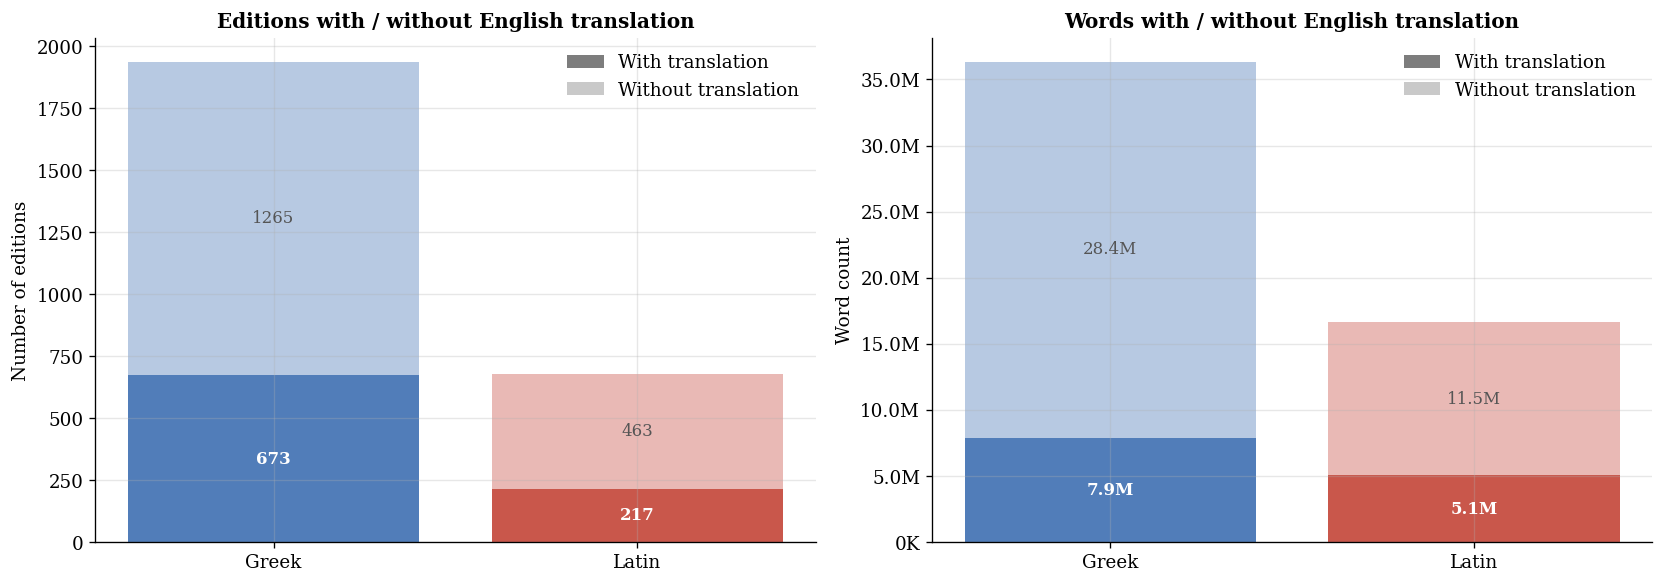

Saved: 03_translation_status.png


In [14]:
# ── Bar chart: translation status by language ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

lang_colors = {'Greek': '#3266ad', 'Latin': '#C0392B'}

# Left: by number of editions
for i, lang in enumerate(['Greek', 'Latin']):
    sub = df_trans[df_trans['language'] == lang]
    if len(sub) == 0:
        continue
    n_with = sub['has_eng'].sum()
    n_without = len(sub) - n_with
    ax1.bar(i, n_with, color=lang_colors[lang], alpha=0.85, label=f'{lang} with')
    ax1.bar(i, n_without, bottom=n_with, color=lang_colors[lang], alpha=0.35)
    ax1.text(i, n_with/2, f'{int(n_with)}', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')
    ax1.text(i, n_with + n_without/2, f'{int(n_without)}', ha='center', va='center',
             fontsize=10, color='#555')

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Greek', 'Latin'])
ax1.set_ylabel('Number of editions')
ax1.set_title('Editions with / without English translation', fontsize=12, fontweight='bold')
# Custom legend
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor='#666', alpha=0.85, label='With translation'),
    Patch(facecolor='#666', alpha=0.35, label='Without translation'),
], frameon=False)

# Right: by word count
for i, lang in enumerate(['Greek', 'Latin']):
    sub = df_trans[df_trans['language'] == lang]
    if len(sub) == 0:
        continue
    w_with = sub[sub['has_eng']]['word_count'].sum()
    w_without = sub[~sub['has_eng']]['word_count'].sum()
    ax2.bar(i, w_with, color=lang_colors[lang], alpha=0.85)
    ax2.bar(i, w_without, bottom=w_with, color=lang_colors[lang], alpha=0.35)
    lbl_w = f'{w_with/1e6:.1f}M' if w_with >= 1e6 else f'{w_with/1e3:.0f}K'
    lbl_wo = f'{w_without/1e6:.1f}M' if w_without >= 1e6 else f'{w_without/1e3:.0f}K'
    ax2.text(i, w_with/2, lbl_w, ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')
    ax2.text(i, w_with + w_without/2, lbl_wo, ha='center', va='center',
             fontsize=10, color='#555')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Greek', 'Latin'])
ax2.set_ylabel('Word count')
ax2.set_title('Words with / without English translation', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
ax2.legend(handles=[
    Patch(facecolor='#666', alpha=0.85, label='With translation'),
    Patch(facecolor='#666', alpha=0.35, label='Without translation'),
], frameon=False)

plt.tight_layout()
plt.savefig('03_translation_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_translation_status.png")

In [15]:
# ── Sortable HTML tables of works without English translations ──

def sortable_table(df_display, title="", table_id="tbl"):
    """Render a DataFrame as a sortable HTML table (click headers to sort)."""
    rows_html = ""
    for _, r in df_display.iterrows():
        rows_html += (
            f"<tr>"
            f"<td>{r['language']}</td>"
            f"<td>{r['author']}</td>"
            f"<td>{r['file']}</td>"
            f"<td>{r['repo']}</td>"
            f"<td style='text-align:right'>{r['word_count']:,}</td>"
            f"<td>{r['century_label']}</td>"
            f"<td>{r['genre']}</td>"
            f"</tr>\n"
        )

    html = f"""
    <h3>{title}</h3>
    <p style="color:#666; font-size:0.9em;">Click any column header to sort.</p>
    <table id="{table_id}" style="border-collapse:collapse; font-size:0.85em; width:100%;">
    <thead>
      <tr style="background:#f0f0f0; cursor:pointer;">
        <th onclick="sortTable('{table_id}',0,'str')">Language ⇅</th>
        <th onclick="sortTable('{table_id}',1,'str')">Author ⇅</th>
        <th onclick="sortTable('{table_id}',2,'str')">File ⇅</th>
        <th onclick="sortTable('{table_id}',3,'str')">Repo ⇅</th>
        <th onclick="sortTable('{table_id}',4,'num')" style="text-align:right">Word count ⇅</th>
        <th onclick="sortTable('{table_id}',5,'str')">Century ⇅</th>
        <th onclick="sortTable('{table_id}',6,'str')">Genre ⇅</th>
      </tr>
    </thead>
    <tbody>
    {rows_html}
    </tbody>
    </table>
    <script>
    var sortDirs = {{}};
    function sortTable(id, col, typ) {{
        var table = document.getElementById(id);
        var tbody = table.querySelector('tbody');
        var rows = Array.from(tbody.querySelectorAll('tr'));
        var key = id + '_' + col;
        sortDirs[key] = !sortDirs[key];
        var asc = sortDirs[key];
        rows.sort(function(a, b) {{
            var av = a.children[col].textContent.trim();
            var bv = b.children[col].textContent.trim();
            if (typ === 'num') {{
                av = parseFloat(av.replace(/,/g, '')) || 0;
                bv = parseFloat(bv.replace(/,/g, '')) || 0;
                return asc ? av - bv : bv - av;
            }}
            return asc ? av.localeCompare(bv) : bv.localeCompare(av);
        }});
        rows.forEach(function(r) {{ tbody.appendChild(r); }});
    }}
    </script>
    <style>
    #{table_id} td, #{table_id} th {{ padding: 4px 8px; border-bottom: 1px solid #ddd; }}
    #{table_id} tbody tr:hover {{ background: #f8f8e8; }}
    </style>
    """
    display(HTML(html))


# Show top 50 untranslated works per language
df_no_eng = df_trans[~df_trans['has_eng']].copy()
df_no_eng = df_no_eng.sort_values('word_count', ascending=False).reset_index(drop=True)

for lang in ['Greek', 'Latin']:
    sub = df_no_eng[df_no_eng['language'] == lang]
    n = len(sub)
    words = sub['word_count'].sum()
    top50 = sub.head(50)
    sortable_table(
        top50,
        title=f"{lang} editions without English translation — top 50 of {n:,} ({words:,} words total)",
        table_id=f"tbl_no_eng_{lang.lower()}"
    )

Language ⇅,Author ⇅,File ⇅,Repo ⇅,Word count ⇅,Century ⇅,Genre ⇅
Greek,Scholia in Homerum,tlg5026.tlg001.1st1K-grc1.xml,First1KGreek,"755,269",,prose
Greek,Suda,tlg9010.tlg001.1st1K-grc1.xml,First1KGreek,"583,818",,prose
Greek,Simplicius,tlg4013.tlg004.1st1K-grc1.xml,First1KGreek,"493,594",,prose
Greek,Alexander of Aphrodisias,tlg0732.tlg004.1st1K-grc1.xml,First1KGreek,"387,770",,prose
Greek,John Philoponus,tlg4015.tlg009.1st1K-grc1.xml,First1KGreek,"368,933",,prose
Greek,Cyril of Alexandria,tlg4090.tlg001.1st1K-grc1.xml,First1KGreek,"357,860",,prose
Greek,Joannes Zonaras,tlg3135.tlg001.1st1K-grc1.xml,First1KGreek,"347,954",,prose
Greek,Simplicius,tlg4013.tlg001.1st1K-grc1.xml,First1KGreek,"311,570",,prose
Greek,Dionysius of Halicarnassus,tlg0081.tlg001.perseus-grc2.xml,Perseus-Greek,"284,276",,prose
Greek,Eustratius,tlg4031.tlg002.1st1K-grc1.xml,First1KGreek,"264,213",,prose


Language ⇅,Author ⇅,File ⇅,Repo ⇅,Word count ⇅,Century ⇅,Genre ⇅
Latin,Augustine,stoa0040.stoa011.opp-lat2.xml,CSEL,"719,858",,prose
Latin,"Jerome, Saint",stoa0162.stoa004.opp-lat1.xml,CSEL,"527,559",,prose
Latin,Augustine,stoa0040.stoa003.opp-lat3.xml,CSEL,"382,554",,prose
Latin,Eugippius,stoa0119.stoa003.opp-lat1.xml,CSEL,"321,139",,prose
Latin,"Hilary, Saint, Bishop of Poitiers",stoa0149b.stoa001.opp-lat1.xml,CSEL,"293,911",,prose
Latin,Lactantius,stoa0171.stoa009.opp-lat1.xml,CSEL,"238,307",,prose
Latin,Catholic Church. Pope.,stoa0045a.stoa001.opp-lat1.xml,CSEL,"221,871",,prose
Latin,John Cassian,stoa0076c.stoa001.opp-lat2.xml,CSEL,"187,081",,prose
Latin,Orosius,stoa0215c.stoa001.opp-lat1.xml,CSEL,"180,702",,prose
Latin,Ambrose,stoa0022.stoa051.opp-lat1.xml,CSEL,"170,629",,prose


## 11. Export

Save the combined dataset to CSV.

In [16]:
# ── Export all dated works to CSV ──

csv_path = 'dated_greek_latin_works.csv'

export_cols = ['file', 'repo', 'language', 'author_code', 'author',
               'century', 'genre', 'word_count', 'century_label']
df_dated[export_cols].to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"Wrote {len(df_dated)} dated works to {csv_path}")
print(f"Columns: {', '.join(export_cols)}")

print(f"\nPreview:")
df_dated[export_cols].head(10)

Wrote 2017 dated works to dated_greek_latin_works.csv
Columns: file, repo, language, author_code, author, century, genre, word_count, century_label

Preview:


,file,repo,language,author_code,author,century,genre,word_count,century_label
0,tlg0057.tlg010.perseus-grc2.xml,Perseus-Greek,Greek,0057,Galen,-1,prose,31809,1st c. BCE
1,tlg0059.tlg009.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,15102,4th c. BCE
2,tlg0059.tlg036.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,16860,4th c. BCE
3,tlg0059.tlg031.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,23755,4th c. BCE
4,tlg0059.tlg007.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,17204,4th c. BCE
5,tlg0059.tlg001.perseus-grc1.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,5392,4th c. BCE
6,tlg0059.tlg006.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,23526,4th c. BCE
7,tlg0059.tlg030.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,mixed,88137,4th c. BCE
8,tlg0059.tlg008.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,18312,4th c. BCE
9,tlg0059.tlg015.perseus-grc2.xml,Perseus-Greek,Greek,0059,Plato,-4,prose,2395,4th c. BCE
